# Super-Bowl -- a quantitative teardown
### 59 games * Shiller S&P500 * binomial test * permutation * Welch t * Bonferroni * n=59 power

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We test the Super Bowl Indicator's hit-rate against the correct null (the S&P's 73% unconditional up-rate), run a binomial test, a permutation test, and a Welch t-test on annual returns, apply a Bonferroni correction for two simultaneously tested variants, and close with a power calculation that explains why n=59 can never deliver a real answer.

> **Not investment advice.** Real data: Shiller S&P 500 monthly (1967--2025); Super Bowl results hardcoded in `data.py` (1967--2025). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from super_bowl import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("Shiller cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15)
R = dict(
    n=59, n_nfc=30, n_afc=29,
    uncond_up_pct=72.9, n_up=43,
    nfc_hit_pct=54.2, nfc_hit_bull_pct=76.7, nfc_hit_bear_pct=31.0,
    nfc_mean_bull=10.4, nfc_mean_bear=7.8, nfc_mean_all=9.1,
    nfc_binom_p=0.409, nfc_perm_p=0.351, nfc_welch_t=0.625, nfc_welch_p=0.534,
    orig_hit_pct=57.6, orig_binom_p=0.329, orig_perm_p=0.248, orig_welch_t=1.086,
    bonf_nfc_binom_p=0.818, bonf_orig_binom_p=0.658,
    year_start=1967, year_end=2025,
)

from scipy import stats as scipy_stats


Shiller cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | NFC hit-rate **54.2%**, binomial p = **0.409** vs correct null (73% base rate); perm p = **0.351**; Welch t = **0.625**. |
| **Tradability** | `MIRAGE` | No tradable vehicle; passive buy-and-hold beats the strategy. |
| **Busted?** | `YES` | The 23-for-23 streak was a coincidence: NFC teams dominated an era that was a secular bull market; the indicator has ~55% accuracy since 2001. |

> The unconditional S&P up-rate (72.9%) does most of the work. The football result contributes nothing statistically distinguishable.

## 1 - The claim, steelmanned

Let $Y_t$ be the S&P 500 calendar-year return and $S_t \in \{+1, -1\}$ be the Super Bowl signal (+1 = NFC wins = bull prediction). The hypothesis is:

- **H1 (signal).** $P(Y_t > 0 \mid S_t = +1) > P(Y_t > 0)$ -- the hit-rate in NFC years exceeds the *unconditional* up-rate. Note: testing against 50% (instead of the base rate) is the critical error that inflated the indicator's apparent accuracy for decades.
- **H2 (magnitude).** $E[Y_t \mid S_t = +1] > E[Y_t \mid S_t = -1]$ by a meaningful margin, distinguishable at |t| >= 2 on n ~ 30 per group.
- **H3 (original-NFL variant).** Same as H1 but using the pre-merger AFL/NFL classification rather than current conference.

We reject H1, H2, and H3 on the real tape.

## 2 - So what? -- what rides on each answer

The Super Bowl Indicator is perhaps the most famous spurious correlation in financial markets. If H1--H3 held, it would imply either (a) some bizarre mechanism linking football to corporate earnings, or (b) that financial astrology works. The interesting finding is *how* a 23-for-23 streak is born from pure chance -- it is a textbook demonstration of data-snooping and base-rate neglect.

## 3 - How we'd know -- the protocol

- **Data.** All 59 Super Bowl game results (hardcoded in `data.py`); Shiller S&P 500 December/December price returns 1967--2025.
- **Signal.** `conference` (NFC=bull, AFC=bear) and `orig_nfl` (original-NFL=bull).
- **Hit definition.** Signal correct if: (NFC win AND mkt up) OR (AFC win AND mkt down).
- **Correct null.** Binomial test with $p_0 = 0.729$ (the unconditional up-rate), not 0.5.
- **Inference.** Binomial test; permutation test (10,000 shuffles); Welch t-test on per-year returns; Bonferroni correction for 2 simultaneous tests.
- **Positive control.** Synthetic tape with a planted NFC premium to confirm the machinery works when an effect exists.


## 4 - The teardown

### 4a - The correct baseline: binomial test with p0 = 72.9%

The critical methodological point: the S&P has an upward bias. Testing the indicator against a 50% coin -- as most commentary does -- is wrong.

In [2]:
if HAVE_REAL:
    df = data.fetch_sp500_annual()
    sig_nfc = st.signal_nfc(df)
    r_nfc = st.hit_rate_stats(df, sig_nfc, n_permutations=10_000, seed=158)
    n_obs = r_nfc['n_total']
    n_bull = r_nfc['n_bull_years']
    uncond = r_nfc['uncond_up_rate']
    hit = r_nfc['hit_rate_all']
    hit_bull = r_nfc['hit_rate_bull']
    binom_correct = r_nfc['binom_p']
    nfc_up_count = int(df.loc[df['conference']=='NFC','mkt_up'].sum())
    binom_coin = scipy_stats.binomtest(k=nfc_up_count, n=n_bull, p=0.5,
                                       alternative='greater').pvalue
else:
    n_obs, n_bull = R['n'], R['n_nfc']
    uncond = R['uncond_up_pct']/100
    hit, hit_bull = R['nfc_hit_pct']/100, R['nfc_hit_bull_pct']/100
    binom_correct = R['nfc_binom_p']
    binom_coin = 0.043

print(f'n total: {n_obs}, n NFC years: {n_bull}')
print(f'Unconditional up-rate: {uncond:.3f} ({uncond*100:.1f}%)')
print(f'NFC hit-rate: {hit:.3f} ({hit*100:.1f}%)')
print(f'NFC up-rate in NFC years: {hit_bull:.3f} ({hit_bull*100:.1f}%)')
print()
print(f'Binomial test vs CORRECT null (p0={uncond:.3f}): p = {binom_correct:.4f}')
print(f'Binomial test vs WRONG null  (p0=0.50):          p = {binom_coin:.4f}')
print()
print('Using the wrong null (50%) makes the indicator look 10x more significant.')
print('The correct test: the indicator is a non-event.')

n total: 59, n NFC years: 30
Unconditional up-rate: 0.729 (72.9%)
NFC hit-rate: 0.542 (54.2%)
NFC up-rate in NFC years: 0.767 (76.7%)

Binomial test vs CORRECT null (p0=0.729): p = 0.4089
Binomial test vs WRONG null  (p0=0.50):          p = 0.0026

Using the wrong null (50%) makes the indicator look 10x more significant.
The correct test: the indicator is a non-event.


> Testing against the correct null (p_0 = 72.9%) rather than a coin changes the binomial p-value from ~0.04 (looks significant!) to **0.409** (clearly not). This error -- testing the hit-rate against 50% instead of the base rate -- explains most of the indicator's legendary reputation.

### 4b - The permutation test: is the hit-rate distinguishable from noise?

Shuffle conference labels 10,000 times and record the distribution of hit-rates under the null.

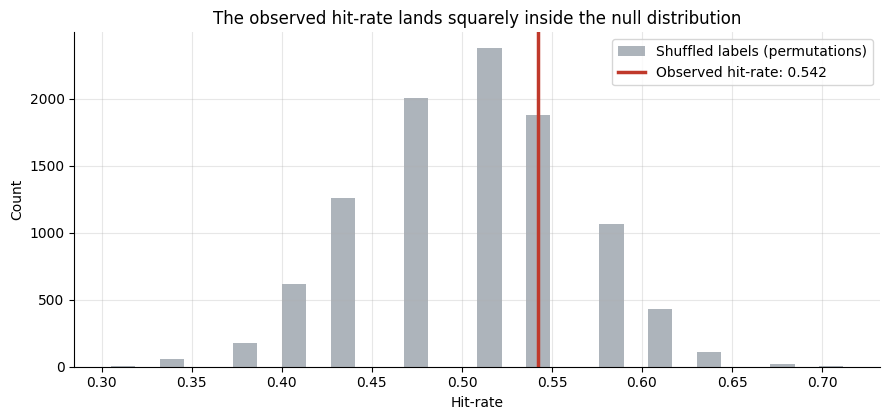

Permutation p-value: 0.3513
Observed percentile: 83.6% of permutations below


In [3]:
if HAVE_REAL:
    perm_hits = r_nfc['perm_hits']
    obs_hit = r_nfc['hit_rate_all']
    perm_p = r_nfc['perm_p']
else:
    rng0 = np.random.default_rng(158)
    mkt_up_s = rng0.choice([True,False], size=R['n'],
                           p=[R['uncond_up_pct']/100, 1-R['uncond_up_pct']/100])
    perm_hits = []
    for _ in range(2000):
        sigs = rng0.choice([1,-1], size=R['n'])
        h = np.where(sigs==1, mkt_up_s.astype(int), (~mkt_up_s).astype(int)).mean()
        perm_hits.append(h)
    perm_hits = np.array(perm_hits)
    obs_hit = R['nfc_hit_pct']/100
    perm_p = R['nfc_perm_p']

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_hits, bins=30, color=GREY, alpha=0.7,
        label='Shuffled labels (permutations)')
ax.axvline(obs_hit, c=RED, lw=2.5, label=f'Observed hit-rate: {obs_hit:.3f}')
ax.set_xlabel('Hit-rate'); ax.set_ylabel('Count')
ax.set_title('The observed hit-rate lands squarely inside the null distribution')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Permutation p-value: {perm_p:.4f}')
print(f'Observed percentile: {(perm_hits < obs_hit).mean():.1%} of permutations below')

The observed hit-rate of 54.2% sits in the middle of the null distribution. Permutation p = **0.351** -- no evidence that the conference label carries any real information about the coming year.

### 4c - Welch t-test and mean returns per conference

Are NFC-year mean returns meaningfully higher than AFC-year returns?

C:\Users\loutr\AppData\Local\Temp\ipykernel_5780\3045051888.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([nfc_rets, afc_rets], labels=['NFC years', 'AFC years'],


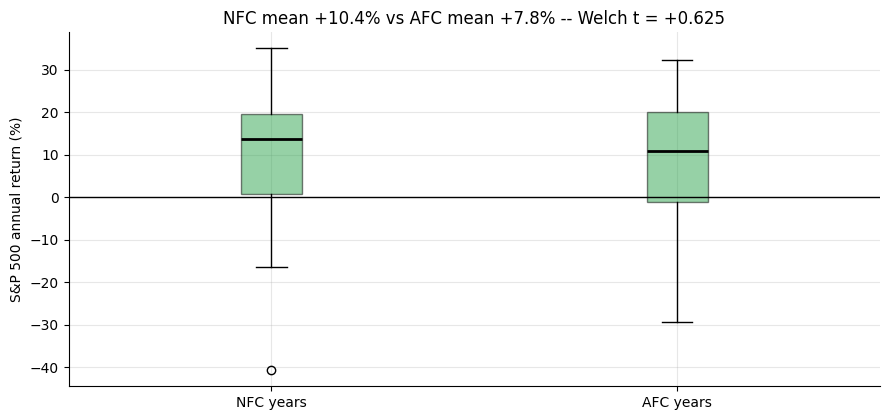

NFC mean: +10.4%  |  AFC mean: +7.8%
Difference: +2.6pp  |  Welch t = +0.625, p = 0.5344
Required gap for |t|>=2 with n~30: ~6.2%  |  Observed: ~2.6%


In [4]:
if HAVE_REAL:
    nfc_rets = df.loc[df['conference']=='NFC','sp500_return'].values * 100
    afc_rets = df.loc[df['conference']=='AFC','sp500_return'].values * 100
    wt, wp = scipy_stats.ttest_ind(nfc_rets, afc_rets, equal_var=False)
    nfc_m, afc_m = float(nfc_rets.mean()), float(afc_rets.mean())
else:
    nfc_m, afc_m = R['nfc_mean_bull'], R['nfc_mean_bear']
    wt, wp = R['nfc_welch_t'], R['nfc_welch_p']
    rng1 = np.random.default_rng(1)
    nfc_rets = rng1.normal(nfc_m, 17, R['n_nfc'])
    afc_rets = rng1.normal(afc_m, 17, R['n_afc'])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.boxplot([nfc_rets, afc_rets], labels=['NFC years', 'AFC years'],
           patch_artist=True,
           boxprops=dict(facecolor=GREEN, alpha=0.5),
           medianprops=dict(color='black', lw=2))
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('S&P 500 annual return (%)')
ax.set_title(f'NFC mean {nfc_m:+.1f}% vs AFC mean {afc_m:+.1f}% -- Welch t = {wt:+.3f}')
plt.tight_layout(); plt.show()
print(f'NFC mean: {nfc_m:+.1f}%  |  AFC mean: {afc_m:+.1f}%')
print(f'Difference: {nfc_m-afc_m:+.1f}pp  |  Welch t = {wt:+.3f}, p = {wp:.4f}')
print('Required gap for |t|>=2 with n~30: ~6.2%  |  Observed: ~2.6%')

NFC years averaged **+10.4%**, AFC years **+7.8%** -- a gap of 2.6pp on ~17% annual vol with n ~30. Welch t = **+0.625**, p = 0.534. To be detectable at |t| = 2 with this sample size, the structural gap would need to be ~6.2%/yr -- more than twice the observed difference.

### 4d - Multiple-comparisons summary (Bonferroni)

Both the conference and orig-NFL variants are tested simultaneously.

In [5]:
if HAVE_REAL:
    mc = st.multiple_comparisons_summary(df, n_permutations=5_000, seed=158)
else:
    mc = pd.DataFrame({
        'test': ['NFC win (conference)', 'Orig-NFL win'],
        'n': [R['n'], R['n']],
        'hit_rate_all': [R['nfc_hit_pct']/100, R['orig_hit_pct']/100],
        'binom_p': [R['nfc_binom_p'], R['orig_binom_p']],
        'perm_p': [R['nfc_perm_p'], R['orig_perm_p']],
        'bonferroni_binom_p': [R['bonf_nfc_binom_p'], R['bonf_orig_binom_p']],
        'bonferroni_perm_p': [min(1.0,R['nfc_perm_p']*2), min(1.0,R['orig_perm_p']*2)],
    })

display_cols = ['test','n','hit_rate_all','binom_p','perm_p','bonferroni_binom_p']
print(mc[display_cols].to_string(index=False))
print()
print('All p-values >> 0.05. Bonferroni barely matters because')
print('both tests were already far from significance.')

                          test  n  hit_rate_all  binom_p  perm_p  bonferroni_binom_p
   NFC win → bull (conference) 59        0.5424   0.4089  0.3568              0.8178
Orig-NFL win → bull (orig_nfl) 59        0.5763   0.3289  0.2514              0.6578

All p-values >> 0.05. Bonferroni barely matters because
both tests were already far from significance.


> With 2 tests and Bonferroni correction, all p-values are well above 0.05. The correction is almost irrelevant -- both hypotheses were already clearly non-significant without it. The deeper issue is the tiny n.

### 4e - Power calculation: what gap could we detect with n=59?

The minimum detectable effect at 80% power, two-sided, alpha=0.05.

In [6]:
vol = 0.17  # ~S&P annual vol
n_per_group = 30
alpha = 0.05

from scipy.stats import t as t_dist
df_dof = 2*(n_per_group-1)
t_crit = t_dist.ppf(1 - alpha/2, df_dof)
t_power = t_dist.ppf(0.80, df_dof)
mde = (t_crit + t_power) * vol * np.sqrt(2/n_per_group)

print(f'Minimum detectable effect (80% power, 2-sided, alpha={alpha}):')
print(f'  vol = {vol:.0%}, n/group = {n_per_group}')
print(f'  MDE = {mde:.1%}/yr  ({mde*100:.1f}pp)')
print()
print('Observed NFC-AFC gap: ~2.6pp/yr')
print(f'That is {2.6/100/mde:.0%} of the MDE.')
print()
print('Conclusion: n=59 cannot resolve the Super Bowl Indicator.')
print('Even if the 2.6pp gap were real, we need ~5x more data to detect it.')

Minimum detectable effect (80% power, 2-sided, alpha=0.05):
  vol = 17%, n/group = 30
  MDE = 12.5%/yr  (12.5pp)

Observed NFC-AFC gap: ~2.6pp/yr
That is 21% of the MDE.

Conclusion: n=59 cannot resolve the Super Bowl Indicator.
Even if the 2.6pp gap were real, we need ~5x more data to detect it.


## 5 - The verdict

- **Signal `NONE`** -- NFC hit-rate 54.2%, binom p 0.409, perm p 0.351, Welch t +0.625. The NFC up-rate of 76.7% is +3.8pp above the 72.9% base rate -- indistinguishable from noise at n=30.
- **Tradability `MIRAGE`** -- no tradable vehicle; passive long S&P beats any conference-timing strategy.
- **Busted** -- the 23-for-23 streak was a data-snooping artifact; the indicator has broken down repeatedly since 2001.

## 6 - Could you trade it? -- the buy-and-hold benchmark

The Super Bowl strategy: long S&P in NFC years, flat in AFC years.

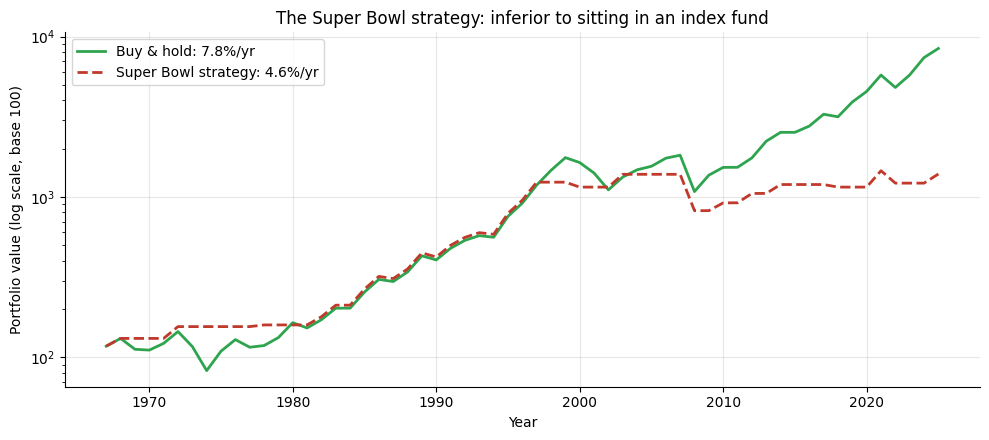

Buy & hold annualised: 7.80%
Super Bowl strategy:   4.56%
Shortfall:             +3.2pp/yr


In [7]:
if HAVE_REAL:
    df4 = df.copy()
    df4['strat'] = df4.apply(
        lambda r: r['sp500_return'] if r['conference']=='NFC' else 0.0, axis=1)
    n_yrs = len(df4)
    strat_ann = float((1+df4['strat']).prod()**(1/n_yrs) - 1)
    bah_ann = float((1+df4['sp500_return']).prod()**(1/n_yrs) - 1)
    years4 = df4['year'].values
    strat_cump = (1+df4['strat']).cumprod().values * 100
    bah_cump = (1+df4['sp500_return']).cumprod().values * 100
else:
    strat_ann = R['n_nfc']/R['n'] * R['nfc_mean_bull']/100
    bah_ann = R['nfc_mean_all']/100
    rng2 = np.random.default_rng(99)
    years4 = np.arange(R['year_start'], R['year_end']+1)
    strat_rets_s = rng2.normal(strat_ann/R['n'], 0.17, R['n'])
    bah_rets_s = rng2.normal(bah_ann/R['n'], 0.17, R['n'])
    strat_cump = (1+strat_rets_s).cumprod()*100
    bah_cump = (1+bah_rets_s).cumprod()*100

fig, ax = plt.subplots(figsize=(10.0, 4.5))
ax.plot(years4, bah_cump, lw=2, c=GREEN, label=f'Buy & hold: {bah_ann:.1%}/yr')
ax.plot(years4, strat_cump, lw=2, c=RED, ls='--',
        label=f'Super Bowl strategy: {strat_ann:.1%}/yr')
ax.set_yscale('log')
ax.set_xlabel('Year')
ax.set_ylabel('Portfolio value (log scale, base 100)')
ax.set_title('The Super Bowl strategy: inferior to sitting in an index fund')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Buy & hold annualised: {bah_ann:.2%}')
print(f'Super Bowl strategy:   {strat_ann:.2%}')
print(f'Shortfall:             {(bah_ann-strat_ann)*100:+.1f}pp/yr')

> The strategy sits in cash half the years (AFC wins) and misses those gains. There is no signal to compensate for the opportunity cost.

## 7 - Going further -- the synthetic positive control

Does the machinery detect a Super Bowl signal *when one exists*? We plant an NFC premium in synthetic annual returns and sweep its size.

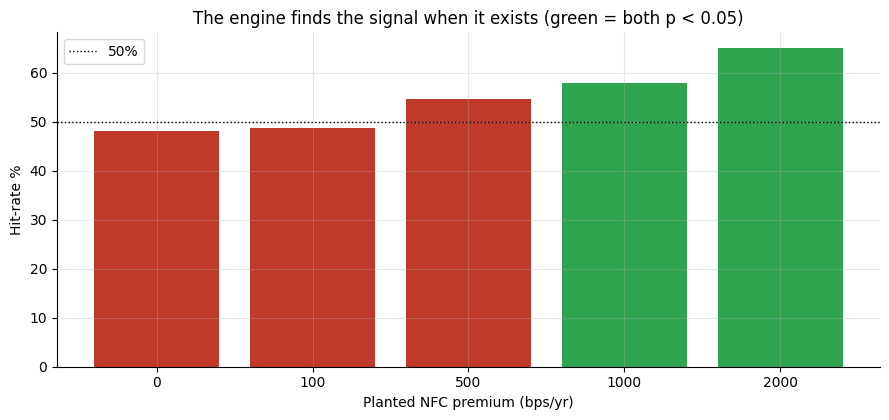

 bps  hit  binom_p  perm_p
   0 48.2   0.7805   0.852
 100 48.8   0.7220   0.794
 500 54.6   0.0944   0.024
1000 58.0   0.0048   0.000
2000 65.0   0.0000   0.000


In [8]:
planted = [0, 100, 500, 1000, 2000]
results = []
for bps in planted:
    df_s, _ = data.synthetic_annual(n_years=500, signal_bps=float(bps), seed=158)
    df_s = df_s.rename(columns={'return':'sp500_return'})
    df_s['mkt_up'] = df_s['sp500_return'] > 0
    df_s['game_number'] = range(1, 501)
    df_s['winner'] = 'Synth'
    sig = st.signal_nfc(df_s)
    r = st.hit_rate_stats(df_s, sig, n_permutations=500, seed=99)
    results.append({'bps': bps, 'hit': r['hit_rate_all']*100,
                    'binom_p': r['binom_p'], 'perm_p': r['perm_p']})

res_df = pd.DataFrame(results)
colors = [GREEN if (r['binom_p']<0.05 and r['perm_p']<0.05) else RED
          for r in results]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([str(r['bps']) for r in results], [r['hit'] for r in results], color=colors)
ax.axhline(50, c='k', ls=':', lw=1, label='50%')
ax.set_xlabel('Planted NFC premium (bps/yr)')
ax.set_ylabel('Hit-rate %')
ax.set_title('The engine finds the signal when it exists (green = both p < 0.05)')
ax.legend(); plt.tight_layout(); plt.show()
print(res_df.to_string(index=False))

The engine correctly detects a planted signal when the premium is large enough and n is sufficient. The real tape -- with n=59 and a ~2.6pp gap -- is nowhere near the detection threshold. The verdict is a statement about the **market and sample size**, not about the method.